## 1. Dataset loading and description

The dataset used in this project consists of DNA sequences in FASTA format, designed for the analysis of acceptor splicing sites.

Two FASTA files are used:
- **Positive sequences**: contain acceptor splicing sites.
- **Negative sequences**: do not contain acceptor splicing sites.

Each file contains **3,200 sequences**, all with a fixed length of **602 nucleotides**.

All sequences, both positive and negative, include the consensus motif **"AG"** at positions **301 and 302**. This design choice is intentional in order to prevent the model from relying solely on the consensus motif. Instead, it encourages the model to learn **other relevant sequence-context features** that allow discrimination between sequences with and without splicing sites.

For data loading and initial preprocessing, the "fasta_to_onehot" function is used to convert the FASTA sequences into a *one-hot encoded* representation.



In [7]:
from utils.function import fasta_to_onehot
from utils.function import fasta_to_onehot, Spliceator, SpliceFinder, DeepSplicer, training_process, plot_all_results


In [2]:
negative_fasta = 'data/half_acceptor_test_negative.fasta'
positive_fasta = 'data/half_acceptor_test_positive.fasta'

df_data = fasta_to_onehot('data/half_acceptor_test_negative.fasta', 'data/half_acceptor_test_positive.fasta')

df_data.head()

,header,sequence,encoding,label
0,seq 20,CCAGCTTGTCACTCTGTTCCTTTTAAGTGTGGCAATAAGTCTGTCT...,"[[0, 1, 0, 0], [0, 1, 0, 0], [1, 0, 0, 0], [0,...",1
1,seq 17,CGGTCGGCTTTCCGGAACCCCATGGGCTTTTACAAGCGCGGCAGGC...,"[[0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 1, 0], [0,...",1
2,seq 16,TTTCCTGTTCATAAAATGTTCTTCTAATCTGGAAAACCAGAATGCT...,"[[0, 0, 0, 1], [0, 0, 0, 1], [0, 0, 0, 1], [0,...",1
3,seq 7,AGAGTAACTACCTGAGTTGTAAAACCAGTTTTGCCATTTTTTGAGT...,"[[1, 0, 0, 0], [0, 0, 1, 0], [1, 0, 0, 0], [0,...",0
4,seq 5,GGAGACCACACAGTAGAGAGCTGGGGGGTGGGGGGGGGGTCAGAAG...,"[[0, 0, 1, 0], [0, 0, 1, 0], [1, 0, 0, 0], [0,...",1


## 2. Dataset Exploration

Before training any model, it is essential to explore the structure and basic properties of the dataset. This step ensures data integrity, verifies class balance, and helps detect potential issues early in the workflow.


In [ ]:
print(df_data.shape)
print(df_data['label'].value_counts())

(40, 4)
label
1    20
0    20
Name: count, dtype: int64


Sequences are encoded using **one-hot encoding**, where each nucleotide (A, C, G, T) is represented as a binary vector of length four. As a result, each sequence is transformed into a matrix of shape **(602, 4)**, preserving positional information along the sequence.The final dataset contains **6,400 sequences**, corresponding to 3,200 positive samples and 3,200 negative samples. Is perfectly balanced between positive and negative classes. This is particularly important for classification tasks, as it prevents model bias toward the majority class and allows for a more reliable evaluation of performance metrics. 


## 6. Deep Learning Models for Splice Site Prediction

In this project, three convolutional neural network (CNN) architectures were evaluated for splice acceptor site prediction: **SpliceFinder**, **DeepSplicer**, and **Spliceator**. Although all models operate on the same one-hot encoded DNA sequences, they differ substantially in architectural depth, convolutional complexity, and regularization strategies.

These architectural differences influence how each model captures biologically relevant sequence patterns, such as short motifs, longer regulatory contexts, and interactions across nucleotide positions.

### 6.1 Model Architecture Overview

Convolutional neural networks are well suited for genomic sequence analysis because convolutional filters can be interpreted as motif detectors, while deeper architectures enable the integration of information across larger genomic contexts.

Below, we describe the key architectural characteristics of each model and their biological implications.

### 6.2 SpliceFinder

SpliceFinder is a relatively shallow CNN architecture composed of a single convolutional layer followed by a fully connected classifier. The convolutional layer uses a kernel size of 9, which allows the model to detect short, localized sequence motifs.

From a biological perspective, this architecture is primarily suited to capturing **local sequence patterns**, such as short regulatory motifs near splice junctions. However, due to its limited depth, SpliceFinder has a reduced capacity to model long-range dependencies or interactions between distant nucleotide positions.

### 6.3 DeepSplicer

DeepSplicer introduces normalization and regularization mechanisms, including batch normalization, L1 and L2 regularization, and multiple dropout layers. Although it contains fewer convolutional layers than Spliceator, its design emphasizes controlled feature learning and generalization.

Biologically, this architecture encourages the model to focus on robust and reproducible sequence features rather than overfitting to specific motifs. This is particularly relevant in splice site prediction, where subtle contextual signals beyond the canonical consensus motif may influence splicing decisions.

### 6.4 Spliceator

Spliceator employs a deeper convolutional architecture with three convolutional blocks of increasing filter numbers (16, 32, 64). Each block progressively expands the receptive field of the model, allowing it to integrate information across longer sequence regions.

From a biological standpoint, deeper architectures like Spliceator are better suited for capturing **hierarchical sequence features**, where low-level motifs combine to form higher-level regulatory patterns associated with splicing regulation.




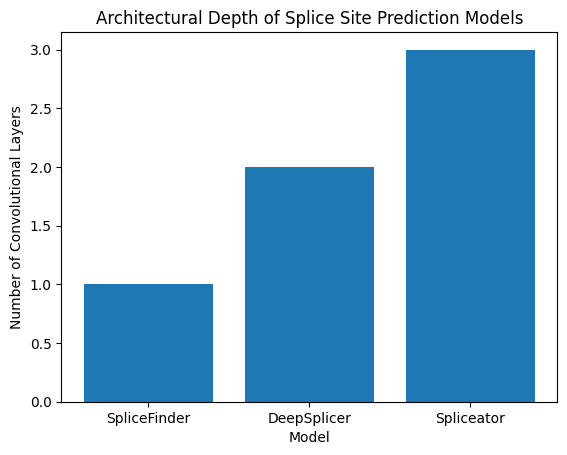

In [6]:
import matplotlib.pyplot as plt

models = ['SpliceFinder', 'DeepSplicer', 'Spliceator']
conv_layers = [1, 2, 3]
kernel_sizes = ['9', '11', '7, 6, 6']

plt.figure()
plt.bar(models, conv_layers)
plt.xlabel('Model')
plt.ylabel('Number of Convolutional Layers')
plt.title('Architectural Depth of Splice Site Prediction Models')
plt.show()


## 7. Model Training and Evaluation

To evaluate the predictive performance of the proposed convolutional neural network architectures, a cross-validation-based training strategy was employed. All models were trained and evaluated using the same dataset, encoding scheme, and optimization parameters to ensure a fair comparison.

### 7.1 Experimental Setup

The dataset was encoded using one-hot encoding and evaluated using **K-fold cross-validation** with two folds. For each fold, models were trained on the training subset and evaluated on the validation subset.

The following performance metrics were computed:
- Loss (binary cross-entropy)
- Accuracy
- Precision
- Recall
- Area Under the ROC Curve (AUC)
- F1-score

This combination of metrics provides a comprehensive assessment of model performance, particularly for binary classification tasks in genomics.

All models were trained using the Adam optimizer and binary cross-entropy loss. Training was performed for a fixed number of epochs to allow direct comparison of convergence behavior across architectures.


In [10]:
cnns = [Spliceator, SpliceFinder, DeepSplicer]

results = training_process(df_data, n_folds=2, cnns=cnns)



--- Training Spliceator ---

Fold 1/2
Epoch 1/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.4000 - auc: 0.3384 - loss: 0.7220 - precision: 0.4286 - recall: 0.2727 - val_accuracy: 0.4500 - val_auc: 0.7424 - val_loss: 0.7193 - val_precision: 0.4500 - val_recall: 1.0000
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.5500 - auc: 0.4747 - loss: 0.7056 - precision: 0.5500 - recall: 1.0000 - val_accuracy: 0.5500 - val_auc: 0.7071 - val_loss: 0.6807 - val_precision: 0.5000 - val_recall: 0.7778
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step

Fold 2/2
Epoch 1/2


c:\Users\Daniela.Sanchez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - auc: 0.4545 - loss: 0.7175 - precision: 0.4706 - recall: 0.8889 - val_accuracy: 0.4500 - val_auc: 0.6111 - val_loss: 1.0063 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.5500 - auc: 0.5707 - loss: 1.0387 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.5500 - val_auc: 0.6869 - val_loss: 0.6755 - val_precision: 0.5500 - val_recall: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step

--- Training SpliceFinder ---

Fold 1/2
Epoch 1/2


c:\Users\Daniela.Sanchez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5000 - auc: 0.4141 - loss: 0.6970 - precision: 0.5294 - recall: 0.8182 - val_accuracy: 0.5500 - val_auc: 0.6162 - val_loss: 0.6983 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 0.2664 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.4500 - val_auc: 0.5354 - val_loss: 2.3500 - val_precision: 0.4500 - val_recall: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step

Fold 2/2
Epoch 1/2


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.5500 - auc: 0.4444 - loss: 0.7004 - precision: 0.5000 - recall: 0.4444 - val_accuracy: 0.4500 - val_auc: 0.6010 - val_loss: 0.7814 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/2
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 747ms/step - accuracy: 0.9500 - auc: 1.0000 - loss: 0.2055 - precision: 1.0000 - recall: 0.8889 - val_accuracy: 0.5500 - val_auc: 0.5960 - val_loss: 1.4641 - val_precision: 0.5500 - val_recall: 1.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step

--- Training DeepSplicer ---

Fold 1/2
Epoch 1/2


c:\Users\Daniela.Sanchez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5500 - auc: 0.6717 - loss: 0.9391 - precision: 0.7500 - recall: 0.2727WARNING:tensorflow:5 out of the last 13 calls to <function TensorFlowTrainer.make_test_function.<locals>.one_step_on_iterator at 0x00000254A67A9120> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5500 - auc: 0.6717 - loss: 0.9391 - precision: 0.7500 - recall: 0.2727 - val_accuracy: 0.4500 - val_auc: 0.4444 - 

c:\Users\Daniela.Sanchez\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\normalization\batch_normalization.py:142: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3000 - auc: 0.3131 - loss: 1.1871 - precision: 0.3077 - recall: 0.4444WARNING:tensorflow:5 out of the last 13 calls to <function TensorFlowTrainer.make_test_function.<locals>.one_step_on_iterator at 0x000002549AE0F420> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.3000 - auc: 0.3131 - loss: 1.1871 - precision: 0.3077 - recall: 0.4444 - val_accuracy: 0.4500 - val_auc: 0.4848 - 

### 7.3 Quantitative Performance Comparison

The table above summarizes the average performance metrics obtained across cross-validation folds for each model architecture.


In [11]:
results['evaluation_metrics']


,cnn,loss,accuracy,precision,recall,auc,f1
0,Spliceator,0.678108,0.550,0.525,0.888889,0.696970,0.461530
1,SpliceFinder,1.907058,0.500,0.500,1.000000,0.565657,0.334816
2,DeepSplicer,0.718149,0.525,0.500,0.055556,0.646465,0.386322


In [12]:
models = [cnn.__name__ for cnn in cnns]

plot_all_results(results, models, save_path="../results")



✨ All plots were successfully generated in '../results/' folder!



### 7.5 ROC Curve Analysis

Receiver Operating Characteristic (ROC) curves were generated for each model to evaluate their ability to discriminate between positive and negative splice sites across different decision thresholds.

The ROC curves illustrate differences in sensitivity–specificity trade-offs between architectures, providing insight into how architectural complexity influences classification behavior.

### 7.6 Confusion Matrix Interpretation

Confusion matrices were computed by aggregating predictions across cross-validation folds. These matrices provide an intuitive representation of classification errors, highlighting false positives and false negatives.

From a biological perspective, false positives may correspond to decoy splice motifs, while false negatives may indicate true splice sites with weak or non-canonical contextual signals.

### 7.7 Architectural Impact on Model Performance

The observed performance differences between models can be interpreted in terms of architectural design:

- **SpliceFinder**, with its shallow architecture, primarily captures short, localized motifs and shows limited capacity to model extended regulatory context.
- **Spliceator**, with multiple convolutional layers, integrates hierarchical sequence features across increasing receptive fields.
- **DeepSplicer**, through extensive regularization, emphasizes robustness and generalization, potentially at the cost of raw expressive power.

These results highlight the trade-offs between architectural simplicity, biological interpretability, and predictive performance in splice site prediction tasks.

